In [1]:
from data_gen import *

import os
import pickle
import random
import networkx as nx
import itertools
from datetime import datetime



In [ ]:
def generate_one_graph(num_node,seed=None):
    """
    生成一个符合要求的图
    :param seed: 随机种子（可选）
    :return: networkx.Graph（带 cell_type、directed、direction 等属性）
    """
    if seed is not None:
        random.seed(seed)
        # 注意：networkx 的 random_tree 依赖全局 random

    n = num_node

    # 2. 动态 extra edges
    max_extra = random.randint(40, max(80, n // 2))

    G_undir = generate_random_planar_cell_graph(
        num_nodes=n,
        max_extra_edges=max_extra,
        seed=seed  # 传入 seed 保证可复现（如果需要）
    )

    # 3. 随机选择替换节点数量
    max_replace = max(3, min(8, G_undir.number_of_nodes() // 5))
    num_replace = random.randint(1, max_replace)

    all_nodes = list(G_undir.nodes())
    if len(all_nodes) < num_replace:
        num_replace = len(all_nodes)
    nodes_to_replace = random.sample(all_nodes, num_replace)

    G = G_undir.copy()
    for node in nodes_to_replace:
        if node in G:
            G = replace_node_with_myo_cycle(G, node)

    # 4. 添加方向属性
    DG = annotate_edge_directions(G, seed=seed)

    # 5. 验证平面性（可选，用于调试）
    UG = nx.Graph(DG)
    is_planar, _ = nx.check_planarity(UG)
    if not is_planar:
        print(f"Warning: Non-planar graph generated with seed {seed}")

    return DG

def batch_generate_graphs(
    num_graphs: int = 500,
    save_dir: str = "generated_graphs",
    save_format: str = "pickle",  # or "graphml"
    min_nodes: int = 50,
    max_nodes: int = 120
):
    """
    批量生成图并保存
    """
    os.makedirs(save_dir, exist_ok=True)

    for i in range(num_graphs):
        # 利用随机种子随机生成节点数
        # seed = int(datetime.now().timestamp() * 1e6) % (2**32) + i
        # 或者简单用 i 作为 seed（更可控）
        seed = i
        num_node = random.randint(min_nodes, max_nodes)
        
        try:
            graph = generate_one_graph(num_node,seed=seed)
            filename = os.path.join(save_dir, f"graph_{i:04d}.{save_format}")

            if save_format == "pickle":
                with open(filename, 'wb') as f:
                    pickle.dump(graph, f)
            else:
                raise ValueError("Unsupported format")

            print(f"Saved {filename} | Nodes: {graph.number_of_nodes()}, Edges: {graph.number_of_edges()}")

        except Exception as e:
            print(f"Failed to generate graph {i}: {e}")
            continue


In [ ]:
if __name__ == "__main__":
    # 批量生成 50 个图
    batch_generate_graphs(
        num_graphs=100,
        save_dir="positive",
        save_format="pickle",  # 推荐 pickle，保留所有属性类型
        min_nodes=50,
        max_nodes=120
    )

#### 生成负样本

In [ ]:
def generate_no_myogenic_cycle(
    num_nodes: int,
    max_extra_edges: int = 15,
    seed: int = None
):
    """
    生成一个连通、平面、无 {MuSC, Myoblast, Myofiber} 三角形的随机细胞图。
    
    :param num_nodes: 节点数（建议 15~80）
    :param max_extra_edges: 在树基础上最多添加的边数
    :param seed: 随机种子（用于可复现性）
    :return: networkx.Graph，每个节点含 'cell_type' 属性，且无 forbidden 三角形
    """
    if seed is not None:
        random.seed(seed)

    # Step 1: 生成随机树（连通、无环、平面）
    G = nx.random_tree(num_nodes, seed=seed)

    # Step 2: 分配细胞类型，并缓存到字典（加速后续查询）
    type_weights = [0.5, 0.3, 0.2]
    cell_assignments = random.choices(CELL_TYPES, weights=type_weights, k=num_nodes)
    cell_types = {}
    for i, ct in enumerate(cell_assignments):
        G.nodes[i]['cell_type'] = ct
        G.nodes[i]['cell_weight'] = NODE_NUMER[ct]
        cell_types[i] = ct

    # Step 3: 获取所有非边并打乱
    all_pairs = itertools.combinations(G.nodes(), 2)
    non_edges = [e for e in all_pairs if not G.has_edge(*e)]
    random.shuffle(non_edges)

    # Step 4: 尝试添加边，同时满足：
    #   (a) 不形成 forbidden 三角形
    #   (b) 保持平面性
    added = 0
    for u, v in non_edges:
        if added >= max_extra_edges:
            break

        # 检查是否会形成 forbidden 三角形
        if no_Mycycle(G, u, v, cell_types):
            continue

        # 检查平面性（临时加边测试）
        G_test = G.copy()
        G_test.add_edge(u, v)
        if nx.check_planarity(G_test)[0]:
            G.add_edge(u, v)
            added += 1

    # 可选：最终验证（调试用，生产可关闭）
    has_forbidden, tri = has_forbidden_myogenic_triangle(G)
    if has_forbidden:
        raise RuntimeError(f"Unexpected forbidden triangle found: {tri}")

    is_planar, _ = nx.check_planarity(G)

    # 赋予方向
    G = annotate_edge_directions(G)
    if not is_planar:
        raise RuntimeError("Graph is not planar!")

    print(f"[No-cycle graph] Nodes: {num_nodes}, Edges: {G.number_of_edges()}, "
          f"Extra edges added: {added}")
    return G

In [ ]:
# --- 批量生成主函数 ---
def batch_generate_no_cycle_graphs(
    num_graphs: int = 1000,
    save_dir: str = "no_myo_cycle_graphs",
    save_format: str = "pkl",  # or "pickle"
    min_nodes: int = 15,
    max_nodes: int = 80,
):
    os.makedirs(save_dir, exist_ok=True)
    
    for i in range(num_graphs):
        # 使用 i 作为 seed，确保可复现且每图不同
        seed = i
        
        # 随机节点数
        num_nodes = random.randint(min_nodes, max_nodes)
        max_extra = random.randint(40, max(80, num_nodes // 2))
        
        try:
            G = generate_no_myogenic_cycle(
                num_nodes=num_nodes,
                max_extra_edges=max_extra,
                seed=seed
            )
            
            filename = os.path.join(save_dir, f"graph_{i:04d}.{save_format}")
            with open(filename, 'wb') as f:
                pickle.dump(G, f)
                
            print(f"[{i+1}/{num_graphs}] Saved {filename} | "
                  f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
                  
        except Exception as e:
            print(f"[{i+1}/{num_graphs}] Failed to generate graph {i}: {e}")
            continue

if __name__ == "__main__":
    batch_generate_no_cycle_graphs(
        num_graphs=50,
        save_dir="negative_samples",  # 负样本目录
        save_format="pickle",
        min_nodes=50,
        max_nodes=120,
    )

In [2]:
# 生成单张graph模拟数据，和真实的组织类似。细胞比例MuSC 30:450:150 => 1:15:5
def generate_one_graph(num_node,seed=None):
    """
    生成一个符合要求的图
    :param seed: 随机种子（可选）
    :return: networkx.Graph（带 cell_type、directed、direction 等属性）
    """
    if seed is not None:
        random.seed(seed)
        # 注意：networkx 的 random_tree 依赖全局 random

    n = num_node

    # 2. 动态 extra edges
    max_extra = random.randint(max(n//2, n // 2), n)

    G_undir = generate_random_planar_cell_graph(
        num_nodes=n,
        max_extra_edges=max_extra,
        seed=seed,  # 传入 seed 保证可复现（如果需要）
        type_weights=[0.05, 0.25, 0.70]
    )

    # 3. 随机选择替换节点数量
    max_replace = max(3, min(8, G_undir.number_of_nodes() // 5))
    num_replace = random.randint(1, max_replace)

    all_nodes = list(G_undir.nodes())
    if len(all_nodes) < num_replace:
        num_replace = len(all_nodes)
    nodes_to_replace = random.sample(all_nodes, num_replace)

    G = G_undir.copy()
    for node in nodes_to_replace:
        if node in G:
            G = replace_node_with_myo_cycle(G, node)

    # 4. 添加方向属性
    DG = annotate_edge_directions(G, seed=seed)

    # 5. 验证平面性（可选，用于调试）
    UG = nx.Graph(DG)
    is_planar, _ = nx.check_planarity(UG)
    if not is_planar:
        print(f"Warning: Non-planar graph generated with seed {seed}")

    return DG

In [6]:
color_map = {
        'MuSC': 'red',
        'Myoblast': 'blue',
        'Myofiber': 'green'
}
def visual_graph(DG, color_map):
    # Step 1: 转为无向图用于布局和绘制
    UG = nx.Graph(DG)

    # Step 2: 尝试使用平面嵌入 + Kamada-Kawai 微调以获得更美观的无交叉布局
    is_planar, embedding = nx.check_planarity(UG)
    if not is_planar:
        print("Warning: Graph is not planar. Falling back to spring layout.")
        pos = nx.spring_layout(UG, seed=42)
    else:
        try:
            # 正确调用：从 embedding 生成初始位置
            # 用该初始位置微调，获得更均匀分布
            init_pos = nx.combinatorial_embedding_to_pos(embedding)
            pos = nx.kamada_kawai_layout(UG, pos=init_pos,weight=None,scale=2)
        except Exception as e:
            print(f"Failed to generate enhanced planar layout: {e}. Using spring layout.")
            pos = nx.spring_layout(UG, seed=42)

    # Step 3: 绘图
    plt.figure(figsize=(8, 6), dpi=400)
    
    # 节点颜色
    colors = [color_map.get(UG.nodes[n].get('cell_type', 'unknown'), 'lightgray') for n in UG.nodes()]
    nx.draw_networkx_nodes(UG, pos, node_color=colors, node_size=80)
    nx.draw_networkx_labels(UG, pos, font_size=6, font_color='white')
    
    # 所有边统一绘制（灰色，无箭头）
    nx.draw_networkx_edges(UG, pos, edge_color='gray', width=1.5, alpha=0.5)

    # 高亮肌管环（红色）
    myo_cycles = get_myo_cycles(DG)
    for cycle in myo_cycles:
        if len(cycle) < 2:
            continue
        cycle_edges = [(cycle[i], cycle[(i + 1) % len(cycle)]) for i in range(len(cycle))]
        nx.draw_networkx_edges(UG, pos, edgelist=cycle_edges, edge_color='red', width=2.5, alpha=0.7)

    # 图例
    legend_elements = [Patch(facecolor=color, label=label) for label, color in color_map.items()]
    plt.legend(handles=legend_elements, title="Node Types", loc='upper right')
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [4]:
G = generate_one_graph(num_node=30,seed=1024)


Generated graph with 30 nodes, 44 edges, 15 extra edges added.


C:\Users\xiaoxu\AppData\Local\Temp\ipykernel_58888\1721930724.py:42: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(UG, pos, edgelist=cycle_edges, edge_color='red', width=2.5, alpha=0.7)


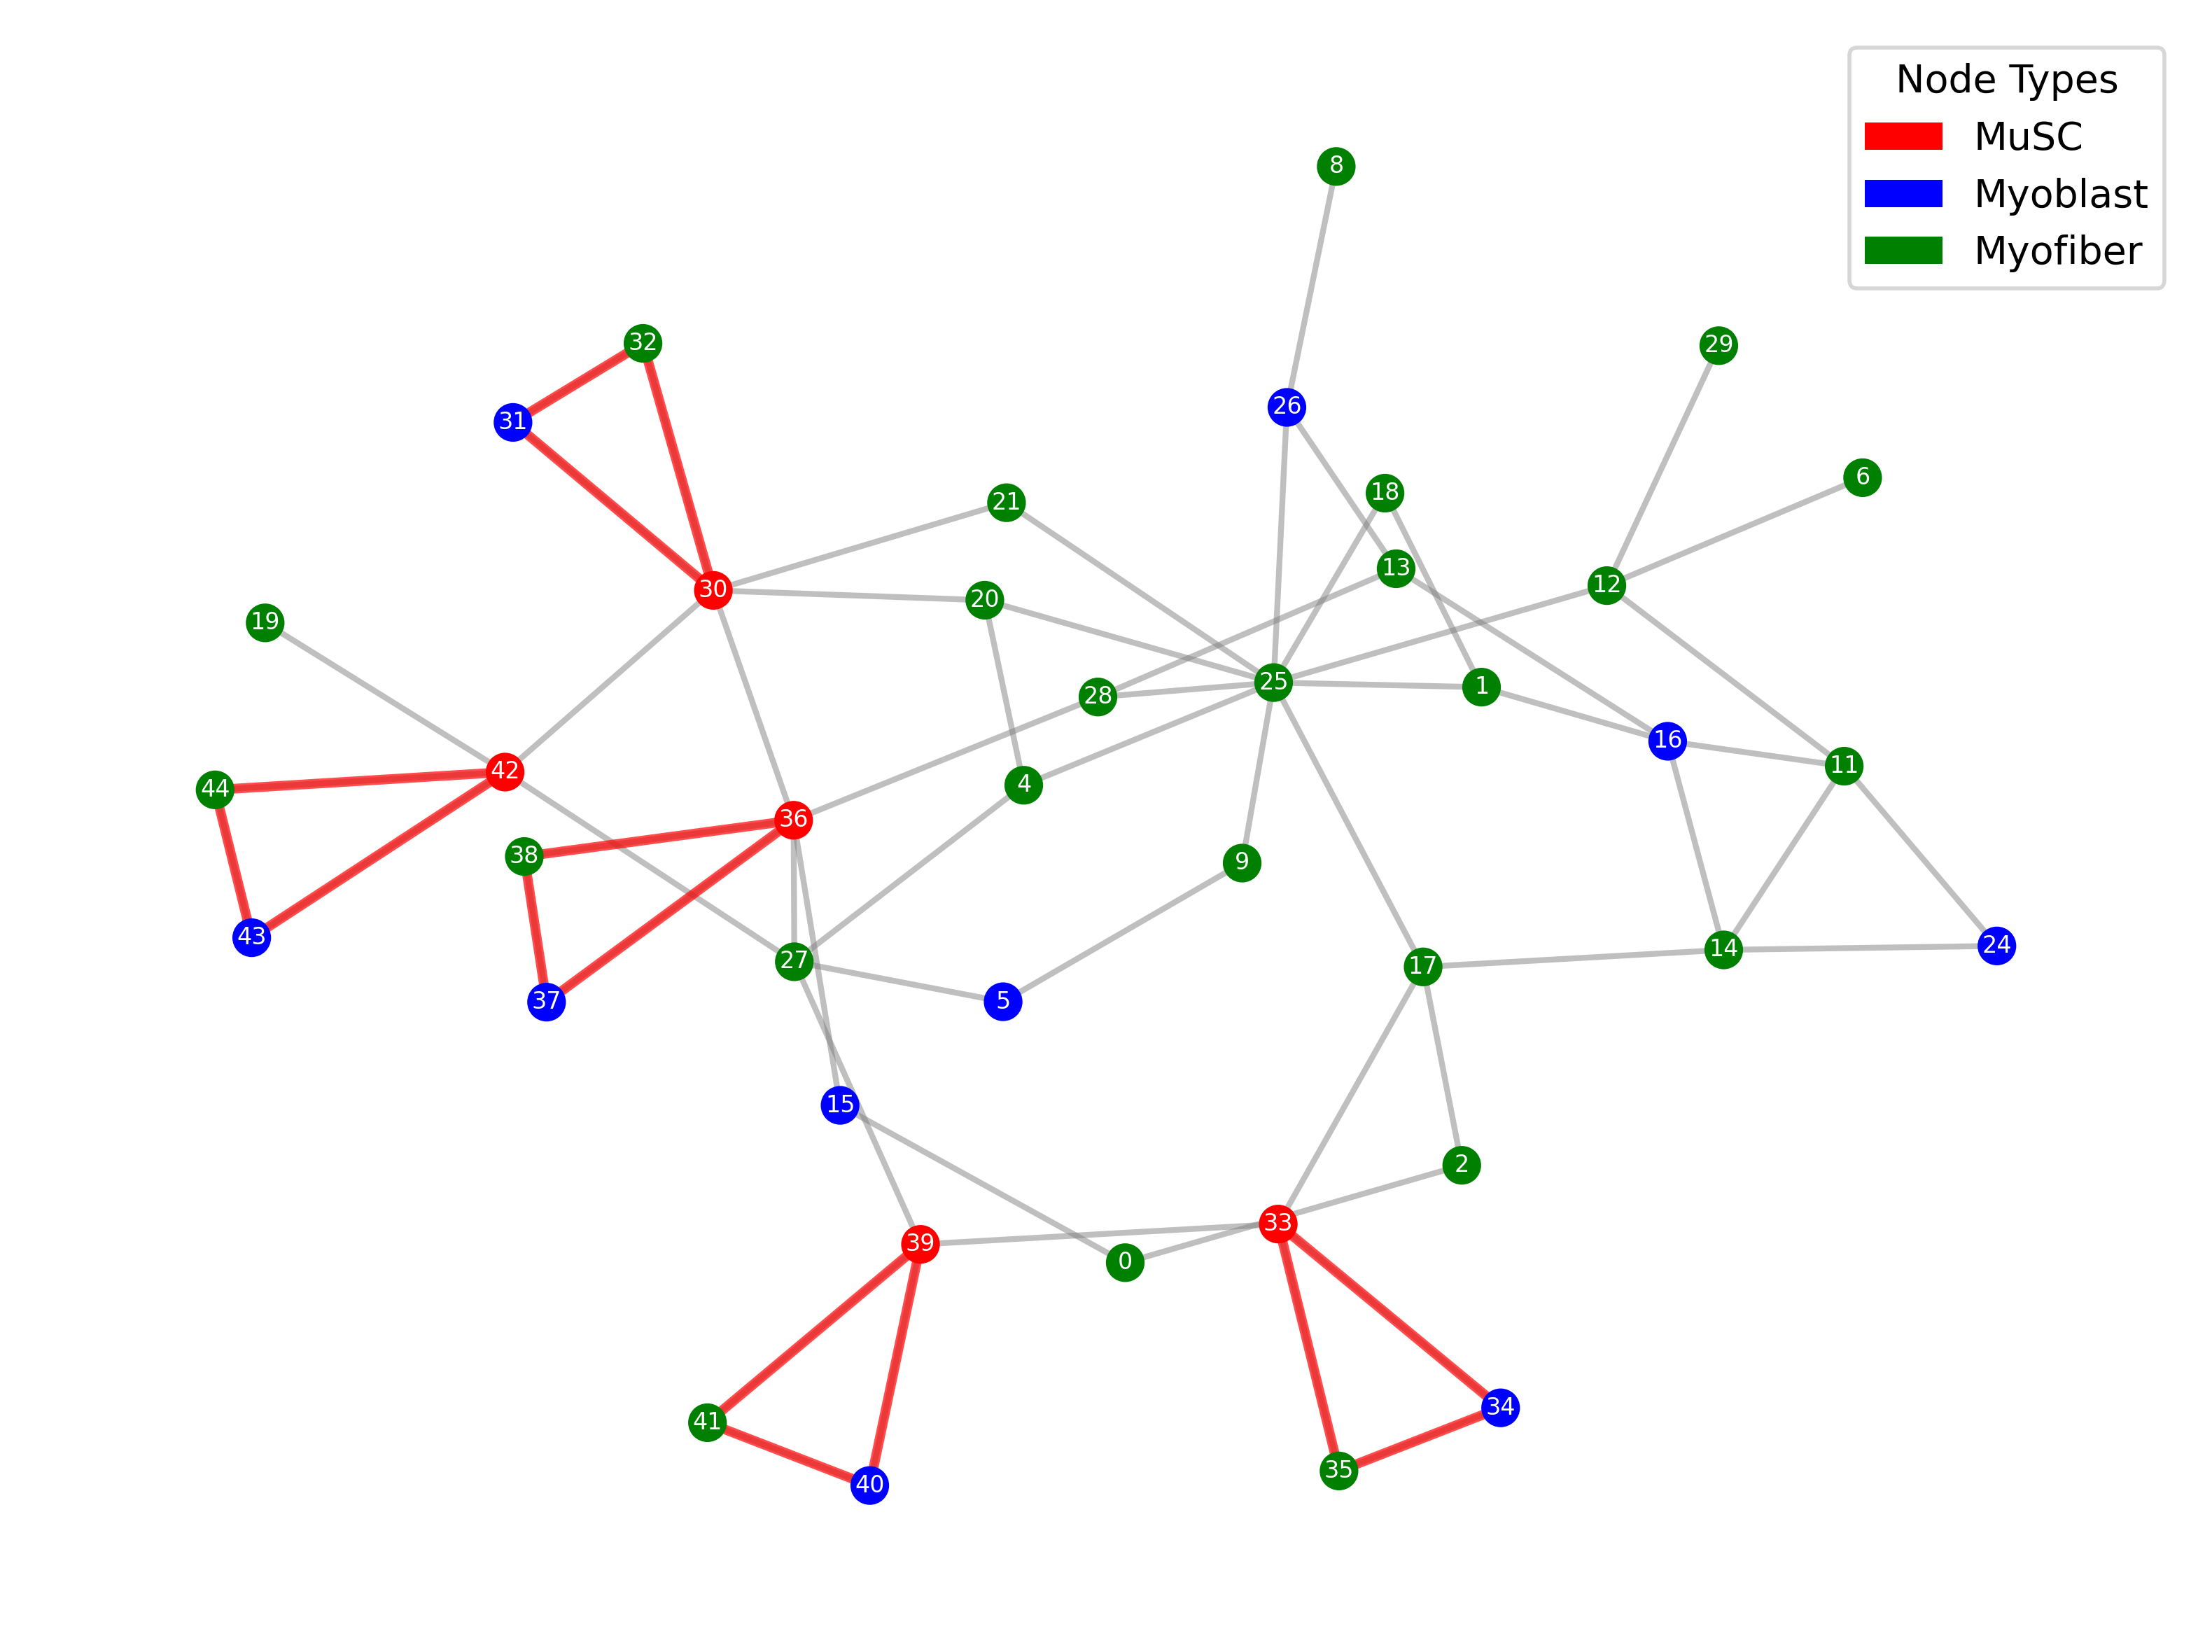

In [7]:
# display
visual_graph(G,color_map)

In [ ]:
# 保存图G pickle文件
with open('graph.pkl', 'wb') as f:
    pickle.dump(G, f)